In [1]:
# Flowerden 1989: modelagem de Poisson (dados de contagem): Variáveis extensive
# Flowerden 1992: modelagem pra dados normais: Variáveis intensive

# To force the estimates to
#satisfy the pycnophylactic property, the source zone estimates
#were scaled by a factor equal to the ratio of the observed value
#to the Ž tted value. Estimated counts for each target unit were
#then obtained by adding the estimates of each subunit com-
#posing the target unit. <- this is exactly the correction term!

#pg 643 de Combining_Incompatible_Spatial_Data

In [31]:
import pandas as pd

In [29]:
# Functions that appends a "Type_" suffix on any numeric column
def rename_type(df):
    res = df.rename(
    columns=lambda col: (
        f"Type_{int(pd.to_numeric(col))}"
        if not isinstance(col, bool)
        and pd.notna(pd.to_numeric(col, errors="coerce"))
        and float(pd.to_numeric(col)).is_integer()
        else col
    ))
    return res

In [19]:
import geopandas as gpd
import matplotlib.pyplot as plt
from libpysal.examples import load_example

from tobler.area_weighted import area_interpolate
from tobler.dasymetric import masked_area_interpolate
from tobler.model import glm
from quilt3 import Package

c1 = load_example("Charleston1")
c2 = load_example("Charleston2")

crs = 6569  # https://epsg.io/6569

source_df = gpd.read_file(c1.get_path("sc_final_census2.shp")).to_crs(crs)
target_df = gpd.read_file(c2.get_path("CharlestonMSA2.shp")).to_crs(crs)

#results_dasy = masked_area_interpolate(
#    raster="nlcd_2011.tif",
#    source_df=source_df,
#    target_df=target_df,
#    pixel_values = [21,22,23,24],
#    extensive_variables=["EMP_MALE"],
#)

In [20]:
# Step 1: Convert raster to vector on source_df
# Step 2: Interpolate source to raster
# Step 3: Count pixels in each source id
# Step 4: Fit the regression

In [21]:
# Internal of masked:

In [22]:
from tobler.dasymetric.raster_tools import extract_raster_features

In [23]:
from tobler.dasymetric import _fast_append_profile_in_gdf

In [24]:
raster_mask = extract_raster_features(source_df, "nlcd_2011.tif", pixel_values = [21,22,23,24], collapse_values=False)

In [25]:
raster_mask.columns

Index(['value', 'geometry'], dtype='object')

In [26]:
raster_mask.shape

(127687, 2)

In [ ]:
raster_mask['value'].value_counts()

In [ ]:
raster_mask.plot()

In [67]:
# Same CRS
raster_mask = raster_mask.to_crs(source_df.crs)

source_df = source_df.copy()
source_df["source_id"] = source_df.index
raster_mask = raster_mask.copy()
raster_mask["mask_id"] = raster_mask.index

variable = 'EMP_MALE'

# Intersect the two layers
source_intersections = gpd.overlay(
    raster_mask[["mask_id", "value", "geometry"]],
    source_df[["source_id", "geometry"]],
    how="intersection"
)

# Count how many intersected pieces of each category fall in each source polygon
source_counts = (
    source_intersections.groupby(["source_id", "value"])
                 .size()
                 .unstack(fill_value=0)
                 .reset_index()
)

source_result = source_df.merge(source_counts, on="source_id", how="left").fillna(0)

In [68]:
source_result = rename_type(source_result)
source_result.head(1)

,FIPS,MSA,TOT_POP,POP_16,POP_65,WHITE_,BLACK_,ASIAN_,HISP_,MULTI_RA,...,POV_POP,POV_TOT,HSG_VAL,POLYID,geometry,source_id,Type_21,Type_22,Type_23,Type_24
0,45015020200,Charlesto,7665,2083,983,2101,5427,30,54,38,...,7520,1908,52300,0,"POLYGON ((725360.513 166693.212, 725312.593 16...",0,1798,1349,433,171


In [155]:
import numpy as np
#formula = ("EMP_MALE ~ -1 + np.log1p(Type_21) + np.log1p(Type_22) + np.log1p(Type_23) + np.log1p(Type_24)")
formula = ("EMP_MALE ~ -1 + Type_21 + Type_22 + Type_23 + Type_24")
import statsmodels.formula.api as smf
import statsmodels.api as sm
#results_regression = smf.poisson(formula, data=source_result).fit()
model = smf.glm(formula, data=source_result, family=sm.families.Poisson())

In [156]:
results_regression = model.fit()
print(results_regression.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:               EMP_MALE   No. Observations:                  117
Model:                            GLM   Df Residuals:                      113
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -4.8822e+05
Date:                Fri, 10 Apr 2026   Deviance:                   9.7544e+05
Time:                        14:12:02   Pearson chi2:                 2.85e+07
No. Iterations:                    17   Pseudo R-squ. (CS):               -inf
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Type_21        0.0014   1.24e-05    111.268      0.0

C:\Users\renan\anaconda3\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1891: RuntimeWarning: overflow encountered in exp
  prsq = 1 - np.exp((self.llnull - self.llf) * (2 / self.nobs))


In [175]:
# You have to extract the log from predict in order to get the weights sums!!
source_result['predito'] = np.log(results_regression.predict(source_result.fillna(0)))

In [176]:
1798*0.0014   +1349*0.0025   +433*0.0015   +171*0.0029   

7.035099999999999

In [177]:
np.exp(7.035099999999999)

np.float64(1135.8084873615733)

In [178]:
source_result.head()

,FIPS,MSA,TOT_POP,POP_16,POP_65,WHITE_,BLACK_,ASIAN_,HISP_,MULTI_RA,...,POV_TOT,HSG_VAL,POLYID,geometry,source_id,Type_21,Type_22,Type_23,Type_24,predito
0,45015020200,Charlesto,7665,2083,983,2101,5427,30,54,38,...,1908,52300,0,"POLYGON ((725360.513 166693.212, 725312.593 16...",0,1798,1349,433,171,7.040537
1,45015020100,Charlesto,7291,1501,739,2899,4259,24,26,62,...,1588,62700,1,"POLYGON ((699159.417 163364.008, 699123.312 16...",1,1929,1024,66,9,5.382537
2,45015020300,Charlesto,8481,2027,1110,6120,2204,10,66,49,...,1148,63700,2,"POLYGON ((726788.75 165836.854, 726748.432 165...",2,1996,1074,266,45,6.004752
3,45035010300,Charlesto,5503,1293,729,2853,2528,35,28,43,...,945,57300,3,"POLYGON ((654886.921 139092.347, 654886.964 13...",3,3487,1126,210,38,8.097257
4,45015020401,Charlesto,3820,877,447,2211,1541,0,5,33,...,648,49000,4,"POLYGON ((754379.548 154140.767, 754397.818 15...",4,2853,871,29,9,6.220698


In [179]:
source_intersections_2 = source_intersections.\
    merge(source_result[['source_id', variable, 'predito']], 
          on="source_id", 
          how="left").\
    fillna(0)

In [180]:
source_intersections_2.head()

,mask_id,value,source_id,geometry,type_coef,EMP_MALE,predito
0,0,22.0,0,"MULTIPOLYGON (((705938.952 184190.388, 705944....",0.000175,1177,7.040537
1,1,23.0,0,"POLYGON ((705944.621 184159.326, 705945.04 184...",0.002155,1177,7.040537
2,2,21.0,0,"POLYGON ((705984.058 184153.106, 705974.503 18...",-0.000022,1177,7.040537
3,3,23.0,0,"POLYGON ((705939.904 184069.568, 705935.127 18...",0.002155,1177,7.040537
4,4,22.0,0,"POLYGON ((705944.682 184098.982, 705939.904 18...",0.000175,1177,7.040537


In [181]:
# Match each pixel gto its corresponding weight

coefs = results_regression.params

# keep only Type_* coefficients
type_coefs = coefs[coefs.index.str.match(r"^Type_\d+$")]

In [182]:
type_coefs

Type_21    0.001385
Type_22    0.002526
Type_23    0.001492
Type_24    0.002907
dtype: float64

In [183]:
# build mapping: 21 -> coef(Type_21), 22 -> coef(Type_22), ...
mapping = {
    int(name.split("_", 1)[1]): coef
    for name, coef in type_coefs.items()
}

# add coefficient as a new column
source_intersections_2["type_coef"] = source_intersections_2["value"].map(mapping)

In [184]:
source_intersections_2.head()

,mask_id,value,source_id,geometry,type_coef,EMP_MALE,predito
0,0,22.0,0,"MULTIPOLYGON (((705938.952 184190.388, 705944....",0.002526,1177,7.040537
1,1,23.0,0,"POLYGON ((705944.621 184159.326, 705945.04 184...",0.001492,1177,7.040537
2,2,21.0,0,"POLYGON ((705984.058 184153.106, 705974.503 18...",0.001385,1177,7.040537
3,3,23.0,0,"POLYGON ((705939.904 184069.568, 705935.127 18...",0.001492,1177,7.040537
4,4,22.0,0,"POLYGON ((705944.682 184098.982, 705939.904 18...",0.002526,1177,7.040537


In [185]:
source_intersections_2['pixel_pop_est'] = source_intersections_2['type_coef'] * (source_intersections_2['EMP_MALE'] / source_intersections_2['predito'])

In [186]:
source_intersections_2.head()

,mask_id,value,source_id,geometry,type_coef,EMP_MALE,predito,pixel_pop_est
0,0,22.0,0,"MULTIPOLYGON (((705938.952 184190.388, 705944....",0.002526,1177,7.040537,0.422200
1,1,23.0,0,"POLYGON ((705944.621 184159.326, 705945.04 184...",0.001492,1177,7.040537,0.249503
2,2,21.0,0,"POLYGON ((705984.058 184153.106, 705974.503 18...",0.001385,1177,7.040537,0.231545
3,3,23.0,0,"POLYGON ((705939.904 184069.568, 705935.127 18...",0.001492,1177,7.040537,0.249503
4,4,22.0,0,"POLYGON ((705944.682 184098.982, 705939.904 18...",0.002526,1177,7.040537,0.422200


In [187]:
# Sum the weights for each source polygon to get the estimated population
sum_by_source = (
    source_intersections_2.groupby("source_id", as_index=False)["pixel_pop_est"]
      .sum()
)

In [188]:
sum_by_source.head()

,source_id,pixel_pop_est
0,0,1177.0
1,1,1171.0
2,2,1860.0
3,3,1180.0
4,4,880.0


In [189]:
sum_by_source['pixel_pop_est'].sum()

np.float64(128317.0)

In [190]:
source_result['EMP_MALE'].sum()

np.int64(128317)

In [192]:
source_result['predito'].sum()

np.float64(247.59296732471446)

In [12]:
#  create a column in the source_df to dissolve on
idx_name = source_df.index.name if source_df.index.name else "idx"
source_df[idx_name] = source_df.index

#  clip source_df by its mask (overlay/dissolve is faster than gpd.clip here)
source_df = gpd.overlay(source_df, raster_mask.to_crs(source_df.crs), how="intersection").dissolve(idx_name)

<Axes: >

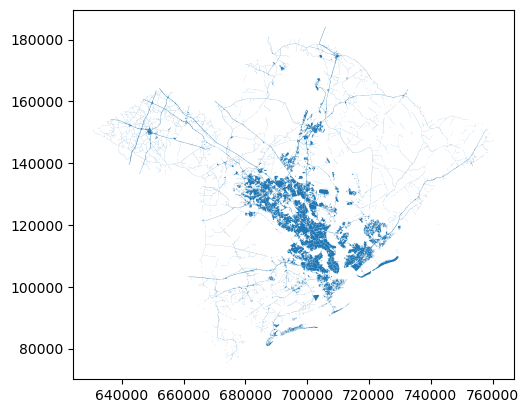

In [13]:
source_df.plot()

In [21]:
source_df.head(1)

,geometry,FIPS,MSA,TOT_POP,POP_16,POP_65,WHITE_,BLACK_,ASIAN_,HISP_,...,EMP_FEM,OCC_MAN,OCC_OFF1,OCC_INFO,HH_INC,POV_POP,POV_TOT,HSG_VAL,POLYID,value
idx,,,,,,,,,,,,,,,,,,,,,
0,"MULTIPOLYGON (((688418.468 176363.948, 688423....",45015020200,Charlesto,7665,2083,983,2101,5427,30,54,...,1302,561,306,4,24612,7520,1908,52300,0,22.0


<Axes: >

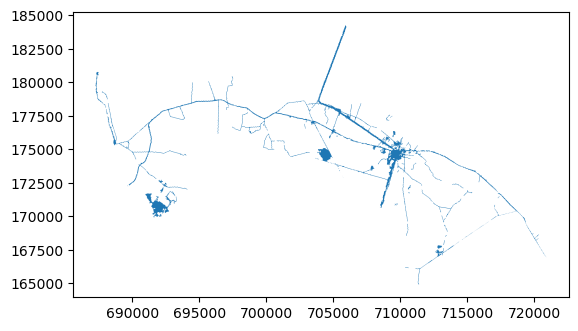

In [20]:
source_df.head(1).plot()

In [32]:
# ChatGPT

import geopandas as gpd
import pandas as pd

# Same CRS
raster_mask = raster_mask.to_crs(source_df.crs)

source_df = source_df.copy()
source_df["source_id"] = source_df.index
raster_mask = raster_mask.copy()
raster_mask["mask_id"] = raster_mask.index

# Intersect the two layers
intersections = gpd.overlay(
    raster_mask[["mask_id", "value", "geometry"]],
    source_df[["source_id", "geometry"]],
    how="intersection"
)

# Count how many intersected pieces of each category fall in each source polygon
counts = (
    intersections.groupby(["source_id", "value"])
                 .size()
                 .unstack(fill_value=0)
                 .reset_index()
)

result = source_df.merge(counts, on="source_id", how="left").fillna(0)

C:\Users\renan\anaconda3\Lib\site-packages\geopandas\tools\overlay.py:358: UserWarning: `keep_geom_type=True` in overlay resulted in 1392 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  result = _collection_extract(result, geom_type, keep_geom_type_warning)


In [41]:
result.head()

,geometry,FIPS,MSA,TOT_POP,POP_16,POP_65,WHITE_,BLACK_,ASIAN_,HISP_,...,POV_POP,POV_TOT,HSG_VAL,POLYID,value,source_id,21.0,22.0,23.0,24.0
0,"MULTIPOLYGON (((688418.468 176363.948, 688423....",45015020200,Charlesto,7665,2083,983,2101,5427,30,54,...,7520,1908,52300,0,22.0,0,1798,1348,431,169
1,"MULTIPOLYGON (((673138.465 153970.04, 673133.6...",45015020100,Charlesto,7291,1501,739,2899,4259,24,26,...,6111,1588,62700,1,21.0,1,1929,1024,66,9
2,"MULTIPOLYGON (((703080.688 163823.373, 703085....",45015020300,Charlesto,8481,2027,1110,6120,2204,10,66,...,8460,1148,63700,2,21.0,2,1996,1074,264,45
3,"MULTIPOLYGON (((649164.724 156145.311, 649153....",45035010300,Charlesto,5503,1293,729,2853,2528,35,28,...,5501,945,57300,3,21.0,3,3487,1126,209,38
4,"MULTIPOLYGON (((708890.892 140845.193, 708861....",45015020401,Charlesto,3820,877,447,2211,1541,0,5,...,3804,648,49000,4,21.0,4,2853,871,29,9


In [55]:
result_renamed = result.rename(
    columns=lambda col: (
        f"Type_{int(pd.to_numeric(col))}"
        if not isinstance(col, bool)
        and pd.notna(pd.to_numeric(col, errors="coerce"))
        and float(pd.to_numeric(col)).is_integer()
        else col
    )
)

In [75]:
result_renamed.head(1)

,geometry,FIPS,MSA,TOT_POP,POP_16,POP_65,WHITE_,BLACK_,ASIAN_,HISP_,...,POV_POP,POV_TOT,HSG_VAL,POLYID,value,source_id,Type_21,Type_22,Type_23,Type_24
0,"MULTIPOLYGON (((688418.468 176363.948, 688423....",45015020200,Charlesto,7665,2083,983,2101,5427,30,54,...,7520,1908,52300,0,22.0,0,1798,1348,431,169


In [79]:
raster_codes = [21,22,23,24]
raster_codes = ["Type_" + str(i) for i in raster_codes]

#formula = (
#            "EMP_MALE"
#            + "~ -1 +"
#            + "+".join(["np.log1p(" + code + ")" for code in raster_codes])
#        )
formula = ("EMP_MALE ~ Type_21 + Type_22 + Type_23 + Type_24")
import statsmodels.formula.api as smf
results_regression = smf.poisson(formula, data=result_renamed).fit()
formula

'EMP_MALE ~ Type_21 + Type_22 + Type_23 + Type_24'

In [80]:
import statsmodels.formula.api as smf
results_regression = smf.poisson(formula, data=result_renamed).fit()

Optimization terminated successfully.
         Current function value: 195.568862
         Iterations 9


In [81]:
results_regression.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                          Poisson Regression Results                          
==============================================================================
Dep. Variable:               EMP_MALE   No. Observations:                  117
Model:                        Poisson   Df Residuals:                      112
Method:                           MLE   Df Model:                            4
Date:                Thu, 09 Apr 2026   Pseudo R-squ.:                  0.2746
Time:                        19:25:52   Log-Likelihood:                -22882.
converged:                       True   LL-Null:                       -31545.
Covariance Type:            nonrobust   LLR p-value:                     0.000
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.7103      0.004   1524.023      0.000       6.702       6.719
Type_21    -2.106e-05   9.78e-06     -2.154      0.031   -4.02e-05   -1.89e-06
Type_22        0.0002   2.49e-05      6.911      0.000       0.000       0.000
Type_23        0.0022   3.72e-05     58.397      0.000       0.002       0.002
Type_24       -0.0036    6.6e-05    -55.192      0.000      -0.004      -0.004
==============================================================================
"""

In [110]:
source_out = result_renamed[[result_renamed.geometry.name, 'EMP_MALE']]
source_out['predito'] = results_regression.predict(result_renamed.drop(columns=[result_renamed.geometry.name]).fillna(0))

C:\Users\renan\anaconda3\Lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [111]:
result_renamed['EMP_MALE'].sum()

np.int64(128317)

In [112]:
source_out['predito'].sum()

np.float64(128317.0)

In [113]:
source_out.columns

Index(['geometry', 'EMP_MALE', 'predito'], dtype='object')

In [114]:
source_out.head()

,geometry,EMP_MALE,predito
0,"MULTIPOLYGON (((688418.468 176363.948, 688423....",1177,1373.864571
1,"MULTIPOLYGON (((673138.465 153970.04, 673133.6...",1171,1049.795844
2,"MULTIPOLYGON (((703080.688 163823.373, 703085....",1860,1426.159819
3,"MULTIPOLYGON (((649164.724 156145.311, 649153....",1180,1269.334742
4,"MULTIPOLYGON (((708890.892 140845.193, 708861....",880,925.357709


In [116]:
source_out['rescale_EMP_MALE'] = source_out['EMP_MALE'] * (source_out['EMP_MALE']/source_out['predito'])

C:\Users\renan\anaconda3\Lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [117]:
source_out.head()

,geometry,EMP_MALE,predito,rescale_EMP_MALE
0,"MULTIPOLYGON (((688418.468 176363.948, 688423....",1177,1373.864571,1008.344657
1,"MULTIPOLYGON (((673138.465 153970.04, 673133.6...",1171,1049.795844,1306.197779
2,"MULTIPOLYGON (((703080.688 163823.373, 703085....",1860,1426.159819,2425.815082
3,"MULTIPOLYGON (((649164.724 156145.311, 649153....",1180,1269.334742,1096.952564
4,"MULTIPOLYGON (((708890.892 140845.193, 708861....",880,925.357709,836.865563


In [118]:
source_out.head()

,geometry,EMP_MALE,predito,rescale_EMP_MALE
0,"MULTIPOLYGON (((688418.468 176363.948, 688423....",1177,1373.864571,1008.344657
1,"MULTIPOLYGON (((673138.465 153970.04, 673133.6...",1171,1049.795844,1306.197779
2,"MULTIPOLYGON (((703080.688 163823.373, 703085....",1860,1426.159819,2425.815082
3,"MULTIPOLYGON (((649164.724 156145.311, 649153....",1180,1269.334742,1096.952564
4,"MULTIPOLYGON (((708890.892 140845.193, 708861....",880,925.357709,836.865563


In [119]:
source_out['EMP_MALE'].sum()

np.int64(128317)

In [ ]:
source_out['predito'].sum()

In [120]:
source_out['rescale_EMP_MALE'].sum()

np.float64(172877.12755766802)

In [ ]:
result_renamed.

<Axes: >

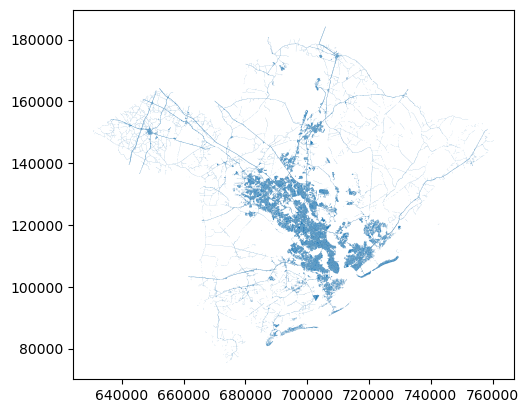

In [37]:
intersections.plot()

In [40]:
intersections.head()

,mask_id,value,source_id,geometry
0,0,22.0,0,"MULTIPOLYGON (((705938.952 184190.388, 705944...."
1,1,23.0,0,"POLYGON ((705944.621 184159.326, 705945.04 184..."
2,2,21.0,0,"POLYGON ((705984.058 184153.106, 705974.503 18..."
3,3,23.0,0,"POLYGON ((705939.904 184069.568, 705935.127 18..."
4,4,22.0,0,"POLYGON ((705944.682 184098.982, 705939.904 18..."


In [85]:
target_df = zip_codes

target_df = target_df.copy()
target_df["target_id"] = target_df.index


# Intersect the two layers
target_intersections = gpd.overlay(
    raster_mask[["mask_id", "value", "geometry"]],
    target_df[["target_id", "geometry"]],
    how="intersection"
)

# Count how many intersected pieces of each category fall in each source polygon
target_counts = (
    target_intersections.groupby(["target_id", "value"])
                 .size()
                 .unstack(fill_value=0)
                 .reset_index()
)

target_result = target_df.merge(target_counts, on="target_id", how="left").fillna(0)

C:\Users\renan\AppData\Local\Temp\ipykernel_45952\2535666491.py:22: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  target_result = target_df.merge(target_counts, on="target_id", how="left").fillna(0)


In [86]:
target_result.head()

,ZIP,PO_NAME,STATE,POP2001,MSA,EST98,EMP98,EFLAG98,PAY98,EST01,...,PCTIME,PCTCSE,PCTGRO,ID,geometry,target_id,21.0,22.0,23.0,24.0
0,29479,SAINT STEPHEN,SC,7403,Charlesto,63,931,0,21675,61,...,-0.43,-4.95,-3.17,0,"POLYGON ((705945.04 184157.035, 706550.696 184...",0,1563,994,275,69
1,29468,PINEVILLE,SC,2185,Charlesto,10,44,0,498,11,...,-1.11,8.90,10.00,1,"POLYGON ((689232.433 173118.41, 689268.102 173...",1,632,511,168,96
2,29018,BOWMAN,SC,4212,Charlesto,38,314,0,4975,41,...,-0.81,6.49,7.89,2,"POLYGON ((650369.615 162054.012, 650141.565 16...",2,172,37,3,0
3,29059,HOLLY HILL,SC,6157,Charlesto,136,2052,0,49945,130,...,-0.32,-6.31,-4.41,3,"POLYGON ((675797.612 160560.778, 674663.566 15...",3,63,59,2,0
4,29431,BONNEAU,SC,5781,Charlesto,43,141,0,2134,50,...,2.81,11.26,16.28,4,"POLYGON ((715201.738 154387.661, 713683.521 15...",4,1222,622,155,20


<Axes: >

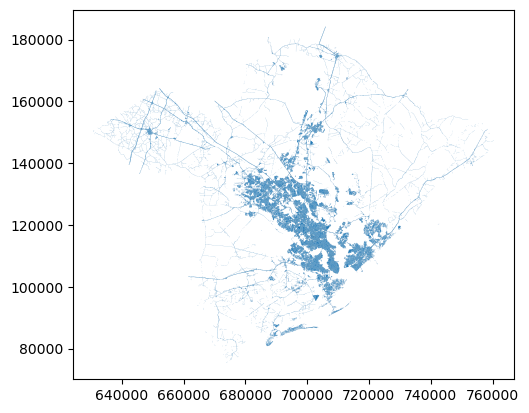

In [88]:
target_intersections.plot()

In [89]:
target_result_renamed = target_result.rename(
    columns=lambda col: (
        f"Type_{int(pd.to_numeric(col))}"
        if not isinstance(col, bool)
        and pd.notna(pd.to_numeric(col, errors="coerce"))
        and float(pd.to_numeric(col)).is_integer()
        else col
    )
)

In [90]:
target_result_renamed.head()

,ZIP,PO_NAME,STATE,POP2001,MSA,EST98,EMP98,EFLAG98,PAY98,EST01,...,PCTIME,PCTCSE,PCTGRO,ID,geometry,target_id,Type_21,Type_22,Type_23,Type_24
0,29479,SAINT STEPHEN,SC,7403,Charlesto,63,931,0,21675,61,...,-0.43,-4.95,-3.17,0,"POLYGON ((705945.04 184157.035, 706550.696 184...",0,1563,994,275,69
1,29468,PINEVILLE,SC,2185,Charlesto,10,44,0,498,11,...,-1.11,8.90,10.00,1,"POLYGON ((689232.433 173118.41, 689268.102 173...",1,632,511,168,96
2,29018,BOWMAN,SC,4212,Charlesto,38,314,0,4975,41,...,-0.81,6.49,7.89,2,"POLYGON ((650369.615 162054.012, 650141.565 16...",2,172,37,3,0
3,29059,HOLLY HILL,SC,6157,Charlesto,136,2052,0,49945,130,...,-0.32,-6.31,-4.41,3,"POLYGON ((675797.612 160560.778, 674663.566 15...",3,63,59,2,0
4,29431,BONNEAU,SC,5781,Charlesto,43,141,0,2134,50,...,2.81,11.26,16.28,4,"POLYGON ((715201.738 154387.661, 713683.521 15...",4,1222,622,155,20


In [94]:
out = target_result_renamed[[target_result_renamed.geometry.name]]
out['predito'] = results_regression.predict(target_result_renamed.drop(columns=[target_result_renamed.geometry.name]).fillna(0))

C:\Users\renan\anaconda3\Lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [100]:
target_result_renamed['EMP_MALE']

KeyError: 'EMP_MALE'

In [95]:
out.head()

,geometry,predito
0,"POLYGON ((705945.04 184157.035, 706550.696 184...",1332.230687
1,"POLYGON ((689232.433 173118.41, 689268.102 173...",898.127238
2,"POLYGON ((650369.615 162054.012, 650141.565 16...",828.419714
3,"POLYGON ((675797.612 160560.778, 674663.566 15...",831.660333
4,"POLYGON ((715201.738 154387.661, 713683.521 15...",1159.201282


In [96]:
out['predito'].sum()

np.float64(92400.83786252947)

In [97]:
tracts['EMP_MALE'].sum()

np.int64(128317)

In [98]:
92400/128317

0.7200916480279308

In [12]:
raster_mask.shape

(25283, 1)

In [9]:
profiled_df = _fast_append_profile_in_gdf(
        tracts, "nlcd_2011.tif"
    )

In [10]:
profiled_df.head()

,geometry,FIPS,MSA,TOT_POP,POP_16,POP_65,WHITE_,BLACK_,ASIAN_,HISP_,...,Type_31,Type_41,Type_42,Type_43,Type_52,Type_71,Type_81,Type_82,Type_90,Type_95
0,"POLYGON ((1494925.111 1268225.174, 1494883.339...",45015020200,Charlesto,7665,2083,983,2101,5427,30,54,...,8311.0,6109.0,62438.0,5683.0,45077.0,5846.0,32464.0,14788.0,204328.0,13998.0
1,"POLYGON ((1469751.085 1260803.204, 1469719.283...",45015020100,Charlesto,7291,1501,739,2899,4259,24,26,...,774.0,3295.0,128216.0,4244.0,71430.0,22573.0,33756.0,14921.0,129590.0,6421.0
2,"POLYGON ((1496462.815 1267598.077, 1496429.301...",45015020300,Charlesto,8481,2027,1110,6120,2204,10,66,...,168.0,783.0,102216.0,5327.0,27928.0,6335.0,22120.0,6630.0,128536.0,7630.0
3,"POLYGON ((1430167.432 1229737.323, 1430159.45 ...",45035010300,Charlesto,5503,1293,729,2853,2528,35,28,...,5216.0,3566.0,98706.0,5773.0,51188.0,13572.0,34471.0,38168.0,176153.0,9668.0
4,"POLYGON ((1525398.224 1260307.365, 1525426.044...",45015020401,Charlesto,3820,877,447,2211,1541,0,5,...,1175.0,1107.0,321167.0,10007.0,70870.0,6478.0,17488.0,3884.0,434327.0,29514.0


<Axes: >

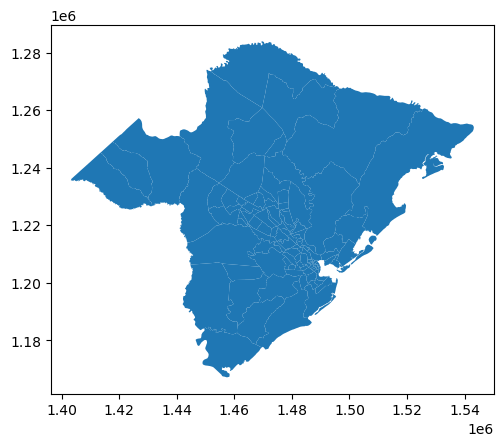

In [11]:
profiled_df.plot()

In [13]:
import geopandas as gpd
import matplotlib.pyplot as plt
from libpysal.examples import load_example

from tobler.area_weighted import area_interpolate
from tobler.dasymetric import masked_area_interpolate
from tobler.model import glm
from quilt3 import Package

c1 = load_example("Charleston1")
c2 = load_example("Charleston2")

crs = 6569  # https://epsg.io/6569

tracts = gpd.read_file(c1.get_path("sc_final_census2.shp")).to_crs(crs)
zip_codes = gpd.read_file(c2.get_path("CharlestonMSA2.shp")).to_crs(crs)


results_area = area_interpolate(
    source_df=tracts,
    target_df=zip_codes,
    extensive_variables=["EMP_MALE"],
)


results_dasy = masked_area_interpolate(
    raster="nlcd_2011.tif",
    source_df=tracts,
    target_df=zip_codes,
    pixel_values = [21,22,23,24],
    extensive_variables=["EMP_MALE"],
)
print(tracts['EMP_MALE'].sum())
print(results_area['EMP_MALE'].sum())
print(results_dasy['EMP_MALE'].sum())

128317
126431.99958410296
126432.00040152704


In [14]:
results_area.head()

,EMP_MALE,geometry
0,1386.002462,"POLYGON ((705945.04 184157.035, 706550.696 184..."
1,316.242787,"POLYGON ((689232.433 173118.41, 689268.102 173..."
2,18.937561,"POLYGON ((650369.615 162054.012, 650141.565 16..."
3,47.577725,"POLYGON ((675797.612 160560.778, 674663.566 15..."
4,1099.362877,"POLYGON ((715201.738 154387.661, 713683.521 15..."


In [15]:
results_dasy.head()

,EMP_MALE,geometry
0,1058.597450,"POLYGON ((705945.04 184157.035, 706550.696 184..."
1,393.691083,"POLYGON ((689232.433 173118.41, 689268.102 173..."
2,40.202535,"POLYGON ((650369.615 162054.012, 650141.565 16..."
3,61.504025,"POLYGON ((675797.612 160560.778, 674663.566 15..."
4,1161.666968,"POLYGON ((715201.738 154387.661, 713683.521 15..."


In [ ]:
- Fast append profile
- Fit the regression
- Adjust before to return the pixel types and use the extract_raster_features
- Apply correction term for each pixel

In [38]:
import statsmodels.formula.api as smf
from statsmodels.genmod.families import Gaussian, NegativeBinomial, Poisson

In [42]:
source_df = tracts
variable = 'EMP_MALE'
raster = 'nlcd_2011.tif'
raster_codes = [21,22,23,24]
force_crs_match = True
liks = {"poisson": Poisson, "gaussian": Gaussian, "neg_binomial": NegativeBinomial}
likelihood="poisson"

In [43]:
str_codes = [str(i) for i in raster_codes]

formula = (
        variable + " ~ -1 + " + " + ".join(["Type_" + s for s in str_codes])
    )

In [44]:
profiled_df = _fast_append_profile_in_gdf(
        source_df[[source_df.geometry.name, variable]], raster, force_crs_match
    )

results = smf.glm(formula, data=profiled_df, family=liks[likelihood]()).fit()

In [46]:
raster_mask = extract_raster_features(tracts, "nlcd_2011.tif", pixel_values = [21,22,23,24], collapse_values=False)

<Axes: >

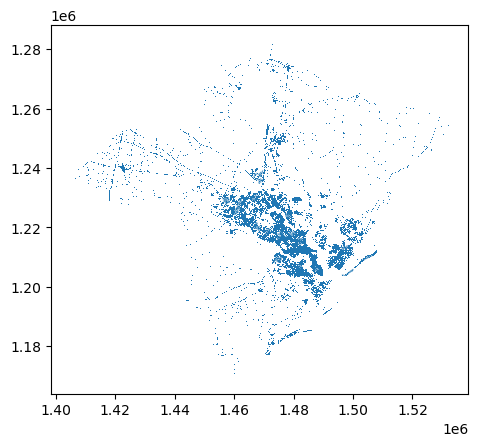

In [48]:
raster_mask.plot()

In [49]:
raster_mask.head()

,value,geometry
0,22.0,"POLYGON ((1473075 1282575, 1473105 1282575, 14..."
1,23.0,"POLYGON ((1473075 1282545, 1473105 1282545, 14..."
2,21.0,"POLYGON ((1473105 1282545, 1473135 1282545, 14..."
3,23.0,"POLYGON ((1473075 1282455, 1473105 1282455, 14..."
4,22.0,"POLYGON ((1473045 1282485, 1473105 1282485, 14..."
